In [55]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

In [56]:
transactions = pd.read_csv(
    "D:/clv/data/processed/clean_transactions.csv"
)

transactions["invoicedate"] = pd.to_datetime(
    transactions["invoicedate"]
)

transactions.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,is_return,revenue,year,month,month_name,day,day_name,hour,quarter,week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,False,83.4,2009,12,December,1,Tuesday,7,4,49
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False,100.8,2009,12,December,1,Tuesday,7,4,49
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False,30.0,2009,12,December,1,Tuesday,7,4,49


In [57]:
sales_df = transactions[
    (~transactions["is_return"]) &
    (~transactions["is_cancelled"])
].copy()

print(f"Total Transactions : {len(transactions):,}")
print(f"Completed Sales    : {len(sales_df):,}")
print(f"Returns/Cancelled  : {len(transactions)-len(sales_df):,}")

Total Transactions : 797,885
Completed Sales    : 779,495
Returns/Cancelled  : 18,390


In [58]:
snapshot_date = sales_df["invoicedate"].max()

print(f"Customers : {sales_df['customer_id'].nunique():,}")
print(f"Invoices  : {sales_df['invoice'].nunique():,}")
print(f"Snapshot  : {snapshot_date}")

Customers : 5,881
Invoices  : 36,975
Snapshot  : 2011-12-09 12:50:00


In [59]:
customer_df = pd.DataFrame({
    "customer_id": sales_df["customer_id"].unique()
})

print("Customers :", len(customer_df))

customer_df.head()

Customers : 5881


,customer_id
0,13085
1,13078
2,15362
3,18102
4,12682


RFM

In [60]:
rfm = (
    sales_df
    .groupby("customer_id")
    .agg(
        recency=("invoicedate",
                 lambda x: (snapshot_date - x.max()).days),

        frequency=("invoice",
                   "nunique"),

        monetary=("revenue",
                  "sum")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    rfm,
    on="customer_id",
    how="left"
)

customer_df.head()

,customer_id,recency,frequency,monetary
0,13085,157,8,2433.28
1,13078,2,57,29018.06
2,15362,448,2,613.08
3,18102,0,145,580987.04
4,12682,3,52,22950.22


In [61]:
spending = (
    sales_df
    .groupby("customer_id")
    .agg(
        avg_order_value=("revenue", "mean"),

        total_orders=("invoice", "nunique"),

        total_revenue=("revenue", "sum"),

        total_products=("quantity", "sum")
    )
    .reset_index()
)

spending["revenue_per_order"] = (
    spending["total_revenue"] /
    spending["total_orders"]
)

spending["avg_revenue_per_product"] = np.where(
    spending["total_products"] > 0,
    spending["total_revenue"] /
    spending["total_products"],
    0
)

customer_df = customer_df.merge(
    spending[
        [
            "customer_id",
            "avg_order_value",
            "revenue_per_order",
            "avg_revenue_per_product"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product
0,13085,157,8,2433.28,28.967619,304.160000,2.577627
1,13078,2,57,29018.06,36.685284,509.088772,2.411740
2,15362,448,2,613.08,15.327000,306.540000,1.665978
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475
4,12682,3,52,22950.22,23.205480,441.350385,2.181165


In [62]:
product_features = (
    sales_df
    .groupby("customer_id")
    .agg(
        total_products=("quantity", "sum"),
        unique_products=("stockcode", "nunique")
    )
    .reset_index()
)

product_features["avg_basket_size"] = (
    product_features["total_products"] /
    customer_df["frequency"].values
)

product_features["product_diversity"] = np.where(
    product_features["total_products"] > 0,
    product_features["unique_products"] /
    product_features["total_products"],
    0
)

customer_df = customer_df.merge(
    product_features,
    on="customer_id",
    how="left"
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,product_diversity
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,0.052966
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,0.012716
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,0.103261
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,0.002103
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,0.031078


In [63]:
lifetime = (
    sales_df
    .groupby("customer_id")
    .agg(
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max")
    )
    .reset_index()
)

lifetime["customer_lifetime_days"] = (
    lifetime["last_purchase"] -
    lifetime["first_purchase"]
).dt.days

lifetime["days_since_first_purchase"] = (
    snapshot_date -
    lifetime["first_purchase"]
).dt.days

customer_df = customer_df.merge(
    lifetime[
        [
            "customer_id",
            "customer_lifetime_days",
            "days_since_first_purchase"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,product_diversity,customer_lifetime_days,days_since_first_purchase
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,0.052966,581,738
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,0.012716,735,738
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,0.103261,290,738
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,0.002103,738,738
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,0.031078,735,738


In [64]:
sales_sorted = (
    sales_df
    .sort_values(["customer_id", "invoicedate"])
)

sales_sorted["purchase_gap"] = (
    sales_sorted
    .groupby("customer_id")["invoicedate"]
    .diff()
    .dt.days
)

purchase_gap = (
    sales_sorted
    .groupby("customer_id")
    .agg(
        avg_purchase_interval=("purchase_gap", "mean")
    )
    .reset_index()
)

customer_df = customer_df.merge(
    purchase_gap,
    on="customer_id",
    how="left"
)

customer_df["avg_purchase_interval"] = (
    customer_df["avg_purchase_interval"]
    .fillna(0)
)

In [65]:
customer_df["purchase_frequency_per_month"] = np.where(
    customer_df["customer_lifetime_days"] > 0,
    customer_df["frequency"] /
    (customer_df["customer_lifetime_days"] / 30),
    customer_df["frequency"]
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,product_diversity,customer_lifetime_days,days_since_first_purchase,avg_purchase_interval,purchase_frequency_per_month
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,0.052966,581,738,6.975904,0.413081
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,0.012716,735,738,0.901266,2.326531
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,0.103261,290,738,7.435897,0.206897
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,0.002103,738,738,0.674687,5.894309
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,0.031078,735,738,0.717611,2.122449


In [66]:
active_months = (
    sales_df
    .assign(
        year_month=sales_df["invoicedate"].dt.to_period("M")
    )
    .groupby("customer_id")["year_month"]
    .nunique()
    .reset_index(name="active_months")
)

customer_df = customer_df.merge(
    active_months,
    on="customer_id",
    how="left"
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,product_diversity,customer_lifetime_days,days_since_first_purchase,avg_purchase_interval,purchase_frequency_per_month,active_months
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,0.052966,581,738,6.975904,0.413081,4
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,0.012716,735,738,0.901266,2.326531,25
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,0.103261,290,738,7.435897,0.206897,2
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,0.002103,738,738,0.674687,5.894309,23
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,0.031078,735,738,0.717611,2.122449,25


In [67]:
favorite_month = (
    sales_df
    .groupby(["customer_id", "month_name"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["customer_id", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("customer_id")
    [["customer_id", "month_name"]]
    .rename(columns={"month_name": "favorite_month"})
)

favorite_day = (
    sales_df
    .groupby(["customer_id", "day_name"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["customer_id", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("customer_id")
    [["customer_id", "day_name"]]
    .rename(columns={"day_name": "favorite_day"})
)

favorite_hour = (
    sales_df
    .groupby(["customer_id", "hour"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["customer_id", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("customer_id")
    [["customer_id", "hour"]]
    .rename(columns={"hour": "favorite_hour"})
)

customer_df = (
    customer_df
    .merge(favorite_month, on="customer_id", how="left")
    .merge(favorite_day, on="customer_id", how="left")
    .merge(favorite_hour, on="customer_id", how="left")
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,product_diversity,customer_lifetime_days,days_since_first_purchase,avg_purchase_interval,purchase_frequency_per_month,active_months,favorite_month,favorite_day,favorite_hour
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,0.052966,581,738,6.975904,0.413081,4,January,Friday,11
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,0.012716,735,738,0.901266,2.326531,25,November,Wednesday,13
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,0.103261,290,738,7.435897,0.206897,2,December,Tuesday,9
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,0.002103,738,738,0.674687,5.894309,23,October,Tuesday,11
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,0.031078,735,738,0.717611,2.122449,25,November,Tuesday,13


In [68]:
country = (
    sales_df
    .groupby(["customer_id", "country"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["customer_id", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("customer_id")
    [["customer_id", "country"]]
)

customer_df = customer_df.merge(
    country,
    on="customer_id",
    how="left"
)

In [69]:
return_features = (
    transactions
    .groupby("customer_id")
    .agg(
        total_transactions=("invoice", "count"),
        total_returns=("is_return", "sum"),
        total_cancelled=("is_cancelled", "sum")
    )
    .reset_index()
)

return_features["return_rate"] = (
    return_features["total_returns"] /
    return_features["total_transactions"]
)

return_features["cancellation_rate"] = (
    return_features["total_cancelled"] /
    return_features["total_transactions"]
)

customer_df = customer_df.merge(
    return_features[
        [
            "customer_id",
            "return_rate",
            "cancellation_rate"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,...,days_since_first_purchase,avg_purchase_interval,purchase_frequency_per_month,active_months,favorite_month,favorite_day,favorite_hour,country,return_rate,cancellation_rate
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,...,738,6.975904,0.413081,4,January,Friday,11,United Kingdom,0.086957,0.086957
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,...,738,0.901266,2.326531,25,November,Wednesday,13,United Kingdom,0.063905,0.063905
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,...,738,7.435897,0.206897,2,December,Tuesday,9,United Kingdom,0.000000,0.000000
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,...,738,0.674687,5.894309,23,October,Tuesday,11,United Kingdom,0.009524,0.009524
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,...,738,0.717611,2.122449,25,November,Tuesday,13,France,0.003024,0.003024


In [70]:
print("Shape :", customer_df.shape)

print("\nMissing Values\n")
print(customer_df.isnull().sum())

print("\nColumns\n")
print(customer_df.columns.tolist())

customer_df.head()

Shape : (5881, 22)

Missing Values

customer_id                     0
recency                         0
frequency                       0
monetary                        0
avg_order_value                 0
revenue_per_order               0
avg_revenue_per_product         0
total_products                  0
unique_products                 0
avg_basket_size                 0
product_diversity               0
customer_lifetime_days          0
days_since_first_purchase       0
avg_purchase_interval           0
purchase_frequency_per_month    0
active_months                   0
favorite_month                  0
favorite_day                    0
favorite_hour                   0
country                         0
return_rate                     0
cancellation_rate               0
dtype: int64

Columns

['customer_id', 'recency', 'frequency', 'monetary', 'avg_order_value', 'revenue_per_order', 'avg_revenue_per_product', 'total_products', 'unique_products', 'avg_basket_size', 'product_diversity

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,...,days_since_first_purchase,avg_purchase_interval,purchase_frequency_per_month,active_months,favorite_month,favorite_day,favorite_hour,country,return_rate,cancellation_rate
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,...,738,6.975904,0.413081,4,January,Friday,11,United Kingdom,0.086957,0.086957
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,...,738,0.901266,2.326531,25,November,Wednesday,13,United Kingdom,0.063905,0.063905
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,...,738,7.435897,0.206897,2,December,Tuesday,9,United Kingdom,0.000000,0.000000
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,...,738,0.674687,5.894309,23,October,Tuesday,11,United Kingdom,0.009524,0.009524
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,...,738,0.717611,2.122449,25,November,Tuesday,13,France,0.003024,0.003024


In [71]:
customer_df["favorite_month"] = customer_df["favorite_month"].astype("category").cat.codes

customer_df["favorite_day"] = customer_df["favorite_day"].astype("category").cat.codes

customer_df["country"] = customer_df["country"].astype("category").cat.codes

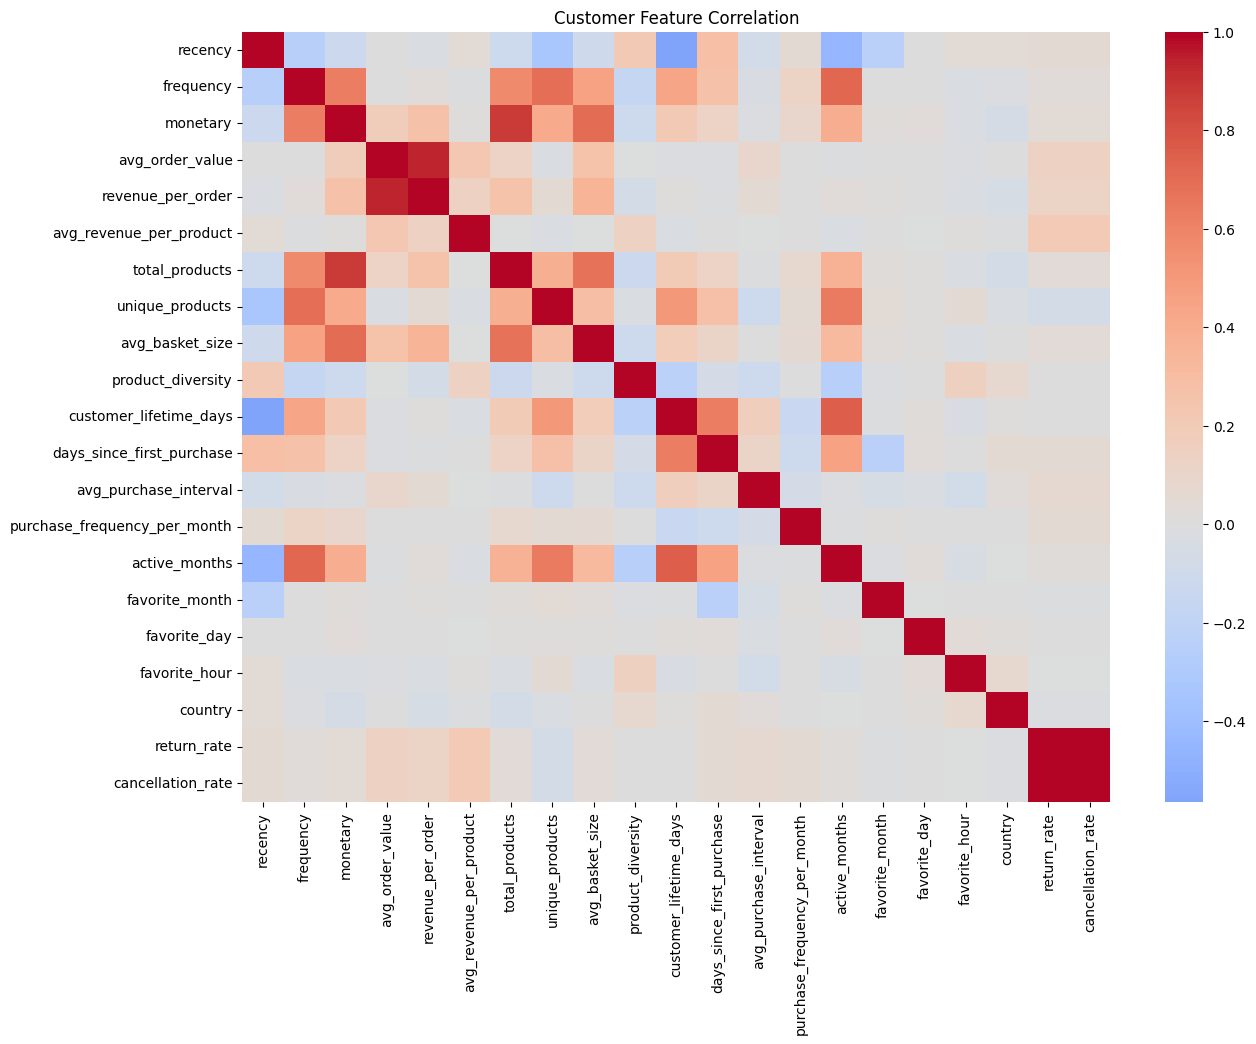

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    customer_df.drop(columns="customer_id").corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Customer Feature Correlation")

plt.show()

In [73]:
customer_df.to_csv(
    "data/processed/customer_features.csv",
    index=False
)

print("customer_features.csv saved successfully!")

customer_features.csv saved successfully!
